In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir("/content/drive/MyDrive/NhanDang/data/")

['digits.npy', 'alphas.npy', 'categorized']

In [3]:
import numpy as np

digits = np.load("/content/drive/MyDrive/NhanDang/data/digits.npy", allow_pickle=True)
alphas = np.load("/content/drive/MyDrive/NhanDang/data/alphas.npy", allow_pickle=True)

print("Digits:", len(digits))
print("Alphas:", len(alphas))

Digits: 3000
Alphas: 6300


In [4]:
from sklearn.model_selection import train_test_split

# Gộp dữ liệu
data = np.concatenate((digits, alphas), axis=0)

images = []
labels = []

for img, label in data:
    images.append(img)
    labels.append(label)

X = np.array(images)
y = np.array(labels)

print("Tổng số mẫu:", len(X))
print("Số lớp:", len(np.unique(y)))

# Chia dữ liệu (giống CNN project của bạn: 15% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train))
print("Validation:", len(X_val))

Tổng số mẫu: 9300
Số lớp: 31
Train: 7905
Validation: 1395


In [5]:
from skimage.feature import hog
import numpy as np

def extract_hog(images):
    hog_features = []
    for img in images:
        img = img.reshape(28, 28)

        feature = hog(
            img,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )

        hog_features.append(feature)

    return np.array(hog_features)

print("Đang trích xuất HOG...")

X_train_hog = extract_hog(X_train)
X_val_hog = extract_hog(X_val)

print("Kích thước vector HOG:", X_train_hog.shape)

Đang trích xuất HOG...
Kích thước vector HOG: (7905, 1296)


In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("Training KNN...")

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_hog, y_train)

y_pred_knn = knn.predict(X_val_hog)
acc_knn = accuracy_score(y_val, y_pred_knn)

print("KNN Accuracy:", acc_knn)

Training KNN...
KNN Accuracy: 0.9562724014336917


In [7]:
from sklearn.svm import SVC

print("Training SVM...")

svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train_hog, y_train)

y_pred_svm = svm.predict(X_val_hog)
acc_svm = accuracy_score(y_val, y_pred_svm)

print("SVM Accuracy:", acc_svm)

Training SVM...
SVM Accuracy: 0.992831541218638


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

X_train_cnn = X_train.reshape(-1,28,28,1) / 255.0
X_val_cnn = X_val.reshape(-1,28,28,1) / 255.0

y_train_cat = to_categorical(y_train, 32)
y_val_cat = to_categorical(y_val, 32)

In [9]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(28,28,1)))
model.add(layers.Conv2D(32,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

model.add(layers.Flatten())
model.add(layers.Dense(512,activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(32,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       819,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        16,416 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 901,120 (3.44 MB)

 Trainable params: 901,120 (3.44 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train_cnn,
    y_train_cat,
    epochs=15,
    batch_size=128,
    validation_data=(X_val_cnn, y_val_cat),
    verbose=1
)

Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 275ms/step - accuracy: 0.1576 - loss: 2.9861 - val_accuracy: 0.9283 - val_loss: 0.2653
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 283ms/step - accuracy: 0.8496 - loss: 0.4557 - val_accuracy: 0.9806 - val_loss: 0.0688
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 25s 398ms/step - accuracy: 0.9474 - loss: 0.1580 - val_accuracy: 0.9900 - val_loss: 0.0346
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 259ms/step - accuracy: 0.9606 - loss: 0.1180 - val_accuracy: 0.9943 - val_loss: 0.0187
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 253ms/step - accuracy: 0.9739 - loss: 0.0792 - val_accuracy: 0.9957 - val_loss: 0.0119
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 250ms/step - accuracy: 0.9763 - loss: 0.0647 - val_accuracy: 0.9964 - val_loss: 0.0120
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 266ms/step - accuracy: 0.9843 - loss: 0.0469 - val_accuracy: 0.9957 - val_loss: 0.0150
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 256ms/step - accuracy: 0.9845 - loss: 0.0507 - val_accu

In [11]:
loss, acc_cnn = model.evaluate(X_val_cnn, y_val_cat)
print("CNN Accuracy:", acc_cnn)

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 1.0000 - loss: 0.0012
CNN Accuracy: 1.0


In [12]:
print("\n===== BẢNG SO SÁNH ACCURACY =====")
print(f"KNN  : {acc_knn*100:.2f}%")
print(f"SVM  : {acc_svm*100:.2f}%")
print(f"CNN  : {acc_cnn*100:.2f}%")


===== BẢNG SO SÁNH ACCURACY =====
KNN  : 95.63%
SVM  : 99.28%
CNN  : 100.00%


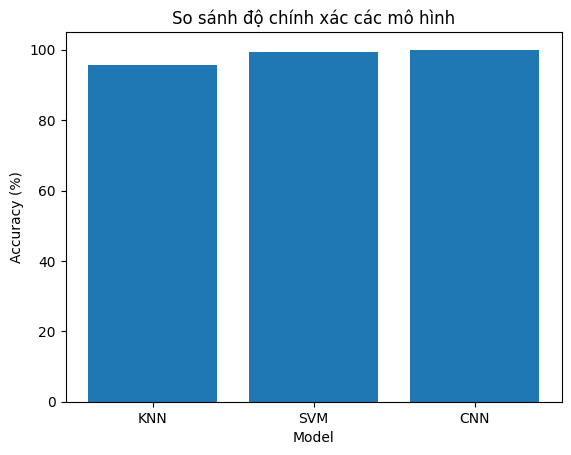

In [13]:
import matplotlib.pyplot as plt

models_name = ['KNN','SVM','CNN']
accuracies = [acc_knn*100, acc_svm*100, acc_cnn*100]

plt.figure()
plt.bar(models_name, accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("So sánh độ chính xác các mô hình")
plt.show()